# Access the analysis ready land cover data

This notebook provides an example of how to open the satellite-land-cover Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds-dev-cci2.copernicus-climate.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds-dev-cci2.copernicus-climate.eu/datasets/how-to-use-the-dss-arco-dataset).

In [ ]:
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked data for access optimised across temporal dimensions (e.g. a time-series plot for a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-048/arco/reanalysis_era5_pressure_levels/pl/geoChunked.zarr"

# Time-chunked data for access optimised across spatial dimensions (e.g. a global map plot for a single time-step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-048/arco/reanalysis_era5_pressure_levels/pl/timeChunked.zarr"
 
# Open the geochunked_url with xarray, users must insert their CDS API key where indicated.
ds = xr.open_zarr(
    geochunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 41TB
Dimensions:        (time: 125964, pressureLevel: 13, latitude: 721,
                    longitude: 1440)
Coordinates:
  * time           (time) datetime64[ns] 1MB 1940-01-01 ... 2026-03-20T18:00:00
  * pressureLevel  (pressureLevel) float64 104B 1e+03 925.0 850.0 ... 100.0 50.0
  * latitude       (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude      (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    q              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    t              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    u              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    v              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    w              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    z              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>

Extract a point, calculate some aggregations with earhtkit-transforms and then plot a time-series using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_67914/2710518862.py:16: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()


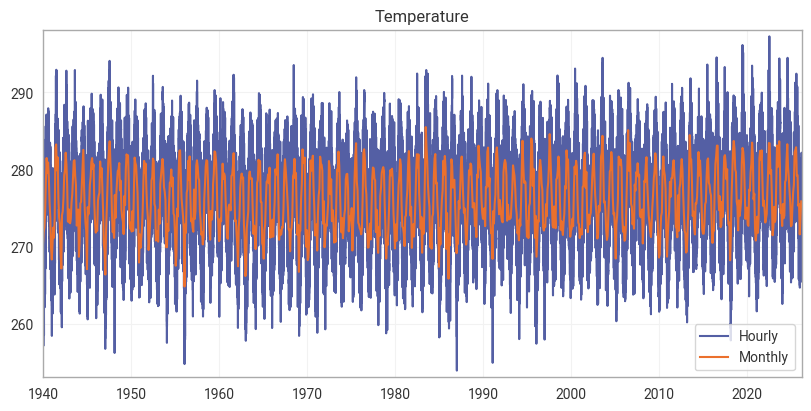

In [3]:
from earthkit import plots as ekp
from earthkit import transforms as ekt

# select variable to plot (Temperature)
variable_name = "t"
location = {
    "latitude": 51.5,
    "longitude": -1.0,
    "pressureLevel": 850
}
plot_data_hourly = ds[variable_name].sel(
    **location, method="nearest"
)
plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

chart = ekp.TimeSeries()

chart.line(plot_data_hourly, label="Hourly")
chart.line(plot_data_monthly, label="Monthly")

chart.title("{variable_name}")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked data for access optimised across temporal dimensions (e.g. a time-series plot for a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-048/arco/reanalysis_era5_pressure_levels/pl/geoChunked.zarr"

# Time-chunked data for access optimised across spatial dimensions (e.g. a global map plot for a single time-step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-048/arco/reanalysis_era5_pressure_levels/pl/timeChunked.zarr"
 
# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 41TB
Dimensions:        (time: 125964, pressureLevel: 13, latitude: 721,
                    longitude: 1440)
Coordinates:
  * time           (time) datetime64[ns] 1MB 1940-01-01 ... 2026-03-20T18:00:00
  * pressureLevel  (pressureLevel) float64 104B 1e+03 925.0 850.0 ... 100.0 50.0
  * latitude       (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude      (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    q              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    t              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    u              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    v              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    w              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>
    z              (time, pressureLevel, latitude, longitude) float32 7TB dask.array<chunksize=(16896, 1, 8, 8), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.